In [ ]:
# streamlink link - https://es335-machine-learning-r7bjkdqjxsy3qq7mfsffp6.streamlit.app/
# models link - https://huggingface.co/BhavayGoyal/Machine_Learning_Assignment_3/tree/main

# All the imports
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
import time
import torch.optim as optim
from sklearn.manifold import TSNE

from utils import MLPTextGenerator, train_model, plot_loss, visualize_embeddings, generate_next_word_natural, tokenize_code, generate_next_word_structured

# NATURAL LANGUAGE

In [3]:
# PREPROCESSING

def process_data(CONTEXT_SIZE):
    file_list = [
    "Data/shake_sphere.txt",
    "Data/leo_tolstoys_war_and_peace.txt", 
    "Data/paul_graham_essays.txt",
    # "Data/enwik8.txt",  
    # "Data/enwik9.txt", 
    "Data/the_adventure_of_sherlock_holmes.txt"
    # "Data/temp.txt" 
    ]

    all_words = []
    for file_path in file_list:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    all_words.extend(['.'])
                    continue
                line = line.replace('.', ' . '); line = re.sub('[^a-zA-Z0. ]', '', line); line = line.lower()
                all_words.extend(line.split())
    all_words.append('.')

    vocab = sorted(list(set(all_words)))
    word_to_ix = {word: i for i, word in enumerate(vocab)}
    ix_to_word = {i: word for i, word in enumerate(vocab)}

    word_counts = Counter(all_words)
    print(f"Total Vocabulary Size: {len(vocab)}\n")
    print("10 Most Frequent Words: - ", word_counts.most_common(10))
    print("10 Least Frequent Words: - ", word_counts.most_common()[:-11:-1])

    X_indices, y_indices = [], [] # Get X, y pairs
    for i in range(len(all_words) - CONTEXT_SIZE):
        context = all_words[i : i + CONTEXT_SIZE]
        target = all_words[i + CONTEXT_SIZE]
        X_indices.append([word_to_ix[w] for w in context])
        y_indices.append(word_to_ix[target])

    return X_indices, y_indices, word_to_ix, ix_to_word

In [4]:
words_to_plot = [
    'i', 'you', 'me', 'my', 'he', 'it', 'they', 'we', 'our', # --- Pronouns & Common Words ---
    'is', 'are', 'was', 'be', 'do', 'does', 'did', 'get', 'make', 'go', 'going', # --- Verbs (and forms) ---
    'startup', 'startups', 'company', 'companies', 'programming', 'code', 'python', 'lisp',  'software', 'computer', 'users', # --- Tech, Startups & Business ---
    'people', 'world', 'time', 'life', 'problem', 'problems', # --- General Nouns & Concepts ---
    'good', 'bad', 'great', 'new', 'old', 'big', 'small', 'much', 'many', # --- Adjectives/Adverbs ---
]

Total Vocabulary Size: 47857

10 Most Frequent Words: -  [('.', 154846), ('the', 90754), ('and', 58173), ('to', 57663), ('of', 47659), ('a', 41558), ('i', 31984), ('in', 29708), ('that', 29162), ('you', 28431)]
10 Least Frequent Words: -  [('newsletter', 1), ('machinereadable', 1), ('licensed', 1), ('orgcontact', 1), ('deductible', 1), ('0c', 1), ('gutenbergs', 1), ('formats', 1), ('deletions', 1), ('modification', 1)]
Data loaded. X shape: (2218264, 10), y shape: 2218264
Created data loaders. Train batches: 1950, Val batches: 217
Using device: cuda
Starting training on cuda for up to 50 epochs...
  [Epoch 1] Batch 200/1950 processed. (1750 left)
  [Epoch 1] Batch 400/1950 processed. (1550 left)
  [Epoch 1] Batch 600/1950 processed. (1350 left)
  [Epoch 1] Batch 800/1950 processed. (1150 left)
  [Epoch 1] Batch 1000/1950 processed. (950 left)
  [Epoch 1] Batch 1200/1950 processed. (750 left)
  [Epoch 1] Batch 1400/1950 processed. (550 left)
  [Epoch 1] Batch 1600/1950 processed. (350 l

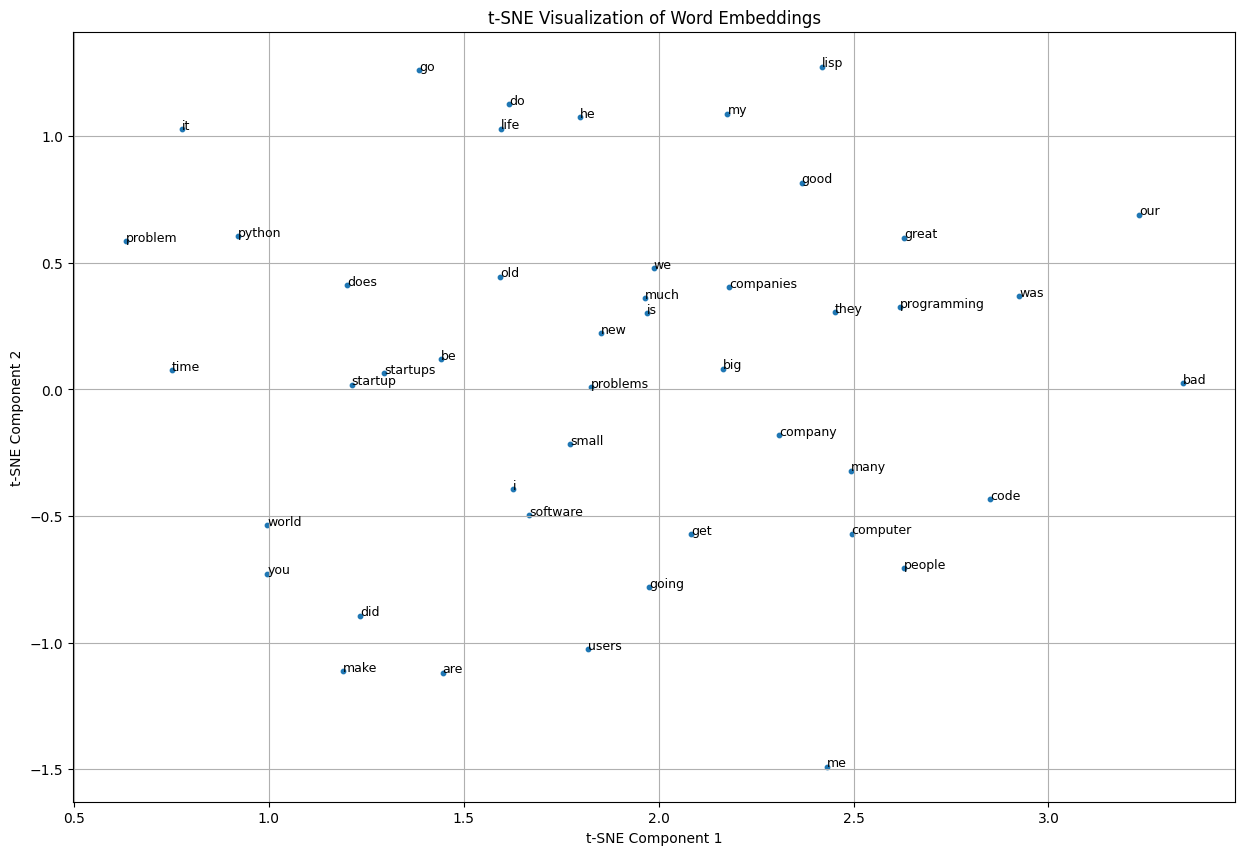

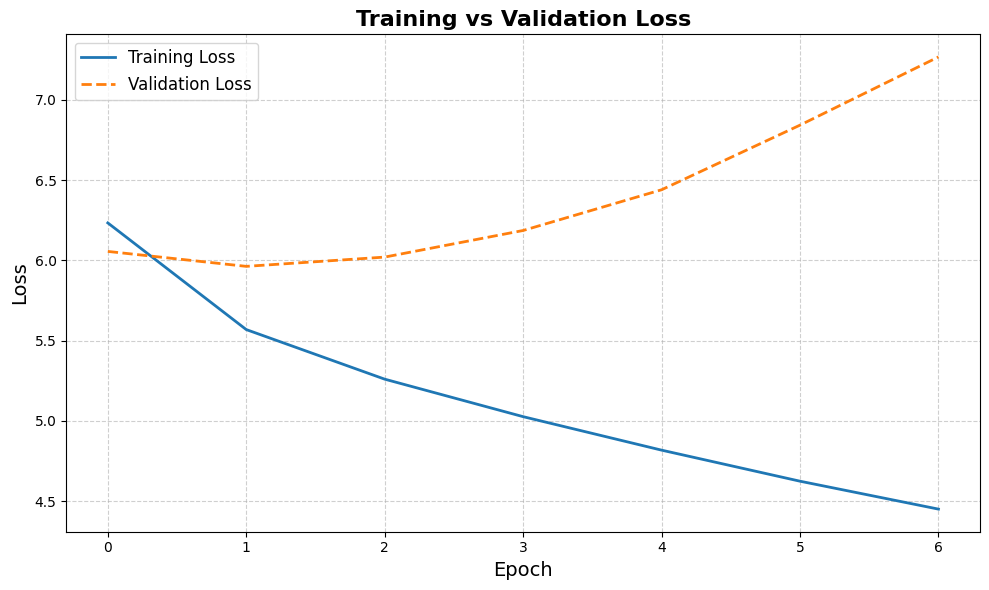

In [5]:
# --- Hyperparameters (You can tune these) ---
CONTEXT_SIZE = 10        # 5 to 10
EMBEDDING_DIM = 64      # 32 or 64
HIDDEN_DIM = 1024       # 1024
NUM_HIDDEN_LAYERS = 3   # 1 or 2
ACTIVATION = 'relu'     # 'relu' or 'tanh'
LEARNING_RATE = 0.001
EPOCHS = 50             # 500-1000 is recommended, but 50 is good for a test
BATCH_SIZE = 1024
TEST_SPLIT = 0.1        # 10% for validation
SEED = 43

torch.manual_seed(43)
np.random.seed(43)

# Start
X_indices, y_indices, word_to_ix, ix_to_word = process_data(CONTEXT_SIZE)
VOCAB_SIZE = len(word_to_ix)
print(f"Data loaded. X shape: {len(X_indices), len(X_indices[0])}, y shape: {len(y_indices)}")

# Convert numpy arrays to torch tensors
X_tensor = torch.tensor(X_indices, dtype=torch.long)
y_tensor = torch.tensor(y_indices, dtype=torch.long)
# Create dataset
dataset = TensorDataset(X_tensor, y_tensor)
val_size = int(len(dataset) * TEST_SPLIT)
train_size = len(dataset) - val_size
# train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_dataset = TensorDataset(X_tensor[:train_size], y_tensor[:train_size]) # first 90% and last 10% data
val_dataset = TensorDataset(X_tensor[train_size:], y_tensor[train_size:])
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Created data loaders. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# --- Initialize Model ---
model = MLPTextGenerator(VOCAB_SIZE=VOCAB_SIZE, EMBEDDING_DIM=EMBEDDING_DIM, CONTEXT_SIZE=CONTEXT_SIZE, HIDDEN_LAYER_DIM=HIDDEN_DIM, NUM_HIDDEN_LAYERS=NUM_HIDDEN_LAYERS, ACTIVATION_TYPE=ACTIVATION)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
visualize_embeddings(model, word_to_ix, words_to_plot, SEED) # PLOT The embeddings before any training
history, model = train_model(model, train_loader, val_loader, LEARNING_RATE, EPOCHS, device)
plot_loss(history)

In [6]:
def append_word(s, nxt):
    s = s.strip()
    if not s: return nxt
    if nxt == '.': return s.rstrip() + nxt
    return s + ' ' + nxt.capitalize() if s.endswith('.') else s + ' ' + nxt

s = "The company is "
for _ in range(20):
    nxt = generate_next_word_natural(model, s, word_to_ix, ix_to_word, CONTEXT_SIZE, device, temperature=1)
    s = append_word(s, nxt)
    print(s)
    if nxt == '.': break

The company is lying
The company is lying a
The company is lying a bet
The company is lying a bet that
The company is lying a bet that find
The company is lying a bet that find the
The company is lying a bet that find the staff
The company is lying a bet that find the staff of
The company is lying a bet that find the staff of consulting
The company is lying a bet that find the staff of consulting rate
The company is lying a bet that find the staff of consulting rate excite
The company is lying a bet that find the staff of consulting rate excite.


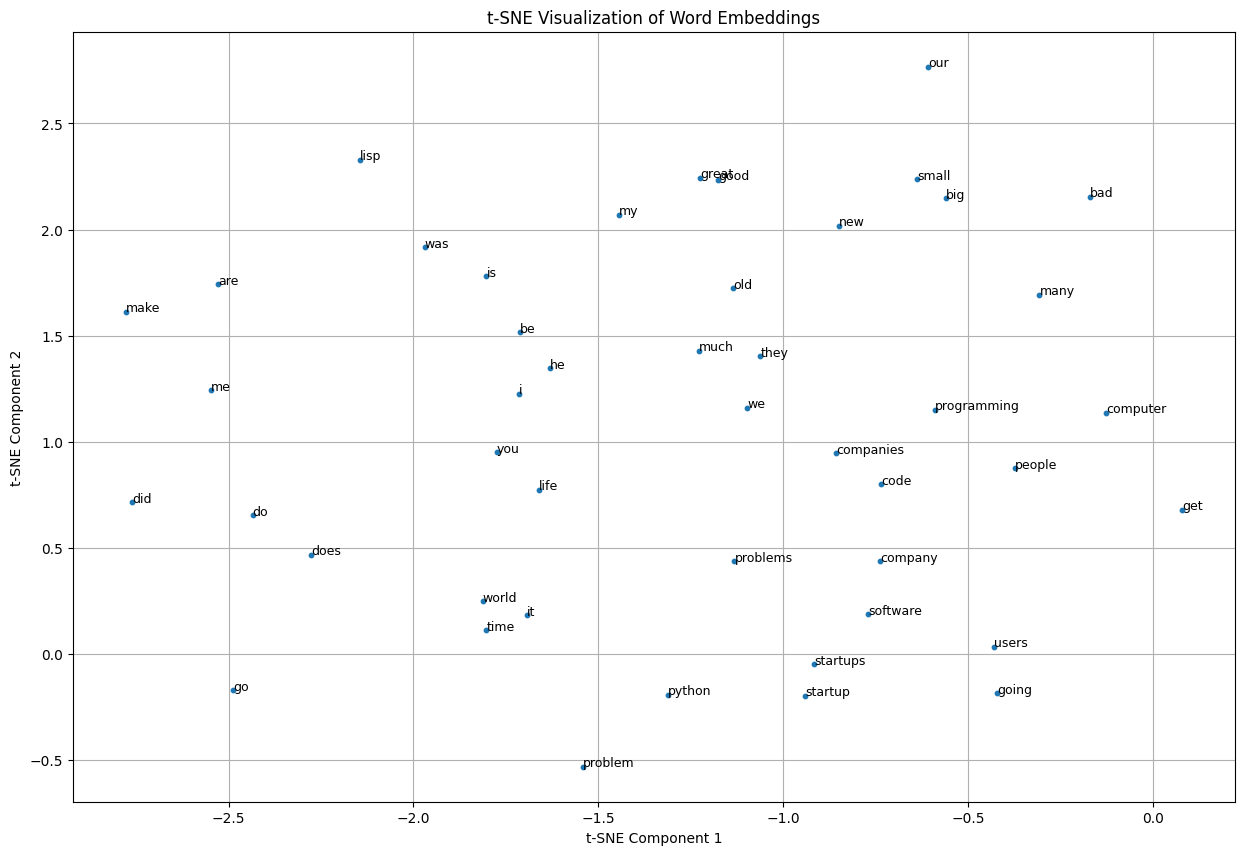

In [7]:
visualize_embeddings(model, word_to_ix, words_to_plot, SEED)

# STRUCTURED LANGUAGE

In [8]:
def process_data(CONTEXT_SIZE):
    files = ["Data2/stacks-project-data.txt"]
    all_words = []

    for path in files:
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line: all_words.extend(tokenize_code(line))

    vocab = sorted(set(all_words))
    word_to_ix = {w: i for i, w in enumerate(vocab)}
    ix_to_word = {i: w for i, w in enumerate(vocab)}

    print(f"Total tokens: {len(all_words)} | Vocabulary size: {len(vocab)}")
    cnt = Counter(all_words)
    print("Top 10:", cnt.most_common(10))
    print("Bottom 10:", cnt.most_common()[:-11:-1])

    X, y = [], []
    for i in range(len(all_words) - CONTEXT_SIZE):
        X.append([word_to_ix[w] for w in all_words[i:i+CONTEXT_SIZE]])
        y.append(word_to_ix[all_words[i+CONTEXT_SIZE]])
    return X, y, word_to_ix, ix_to_word

In [9]:
words_to_plot = [
    # LaTeX Commands
    '\\documentclass', '\\usepackage', '\\begin', '\\end', '\\section', '\\subsection',
    '\\textbf', '\\textit', '\\underline', '\\emph', '\\title', '\\author', '\\date',
    '\\maketitle', '\\tableofcontents', '\\item', '\\includegraphics', '\\caption', '\\label', '\\ref',
    '\\cite', '\\footnote', '\\frac', '\\sum', '\\alpha', '\\beta', '\\gamma', '\\infty', '\\rightarrow',
    # Common Symbols
    '{', '}', '[', ']', '(', ')', '$', '%', '&', '_', '^', '~', '=', '+', '-', '*', '/',
    # Math and Formatting
    '\\sqrt', '\\pi', '\\int', '\\lim', '\\sin', '\\cos', '\\tan', '\\log', '\\exp',
    # English Words
    'introduction', 'method', 'result', 'discussion', 'conclusion', 'figure', 'table', 'proof', 'theorem',
    # Mixed Tokens
    '\\textbf{Example}', '\\section{Results}', '\\frac{a}{b}', '\\alpha + \\beta = \\gamma'
]

Total tokens: 8468301 | Vocabulary size: 12997
Top 10: [('$', 904830), ('{', 486749), ('}', 486648), ('-', 337705), (',', 199511), ('.', 199003), ('(', 191818), (')', 191792), ('\\mathcal', 131698), ('the', 124244)]
Bottom 10: [('converts', 1), ('Missing', 1), ('equidmensional', 1), ('equdimensional', 1), ('supplementary', 1), ('Deails', 1), ('coclude', 1), ('hypothese', 1), ('Correspondences', 1), ('Equipped', 1)]
Data loaded. X shape: (8468286, 15), y shape: 8468286
Created data loaders. Train batches: 7443, Val batches: 827
Created data loaders. Train batches: 7443, Val batches: 827
Using device: cuda
Starting training on cuda for up to 50 epochs...
  [Epoch 1] Batch 200/7443 processed. (7243 left)
  [Epoch 1] Batch 400/7443 processed. (7043 left)
  [Epoch 1] Batch 600/7443 processed. (6843 left)
  [Epoch 1] Batch 800/7443 processed. (6643 left)
  [Epoch 1] Batch 1000/7443 processed. (6443 left)
  [Epoch 1] Batch 1200/7443 processed. (6243 left)
  [Epoch 1] Batch 1400/7443 processed

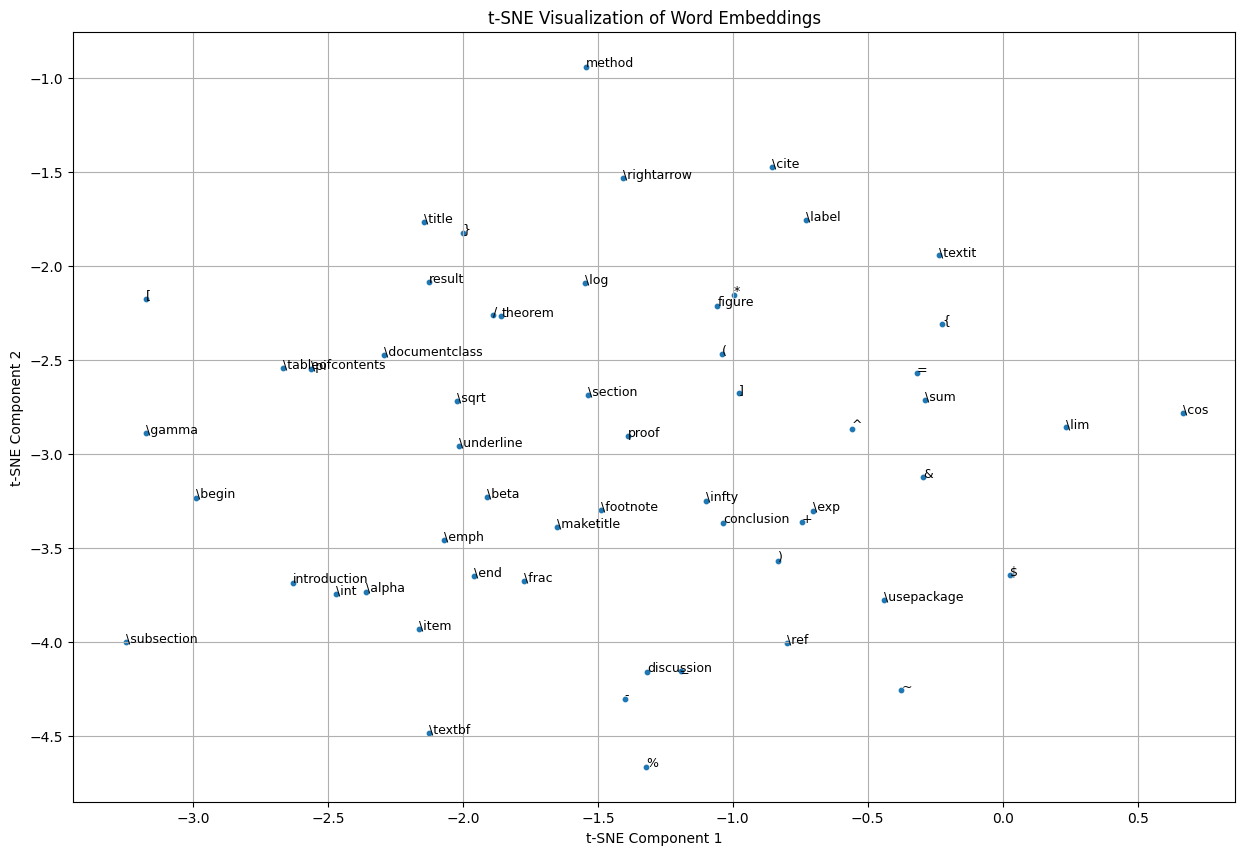

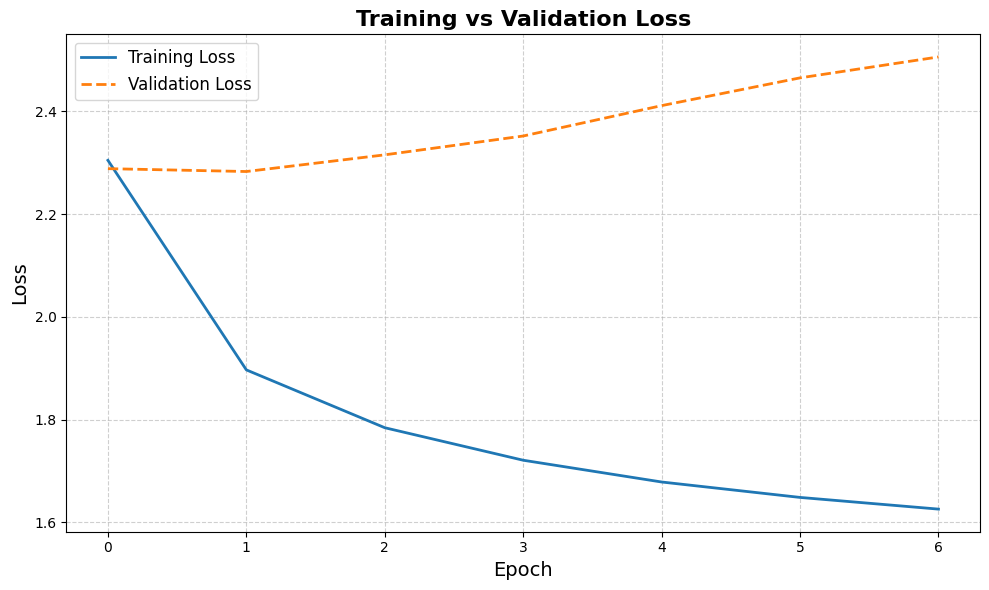

In [10]:
# --- Hyperparameters (You can tune these) ---
CONTEXT_SIZE = 15        # 5 to 10
EMBEDDING_DIM = 64      # 32 or 64
HIDDEN_DIM = 1024       # 1024
NUM_HIDDEN_LAYERS = 2   # 1 or 2
ACTIVATION = 'relu'     # 'relu' or 'tanh'
LEARNING_RATE = 0.001
EPOCHS = 50             # 500-1000 is recommended, but 50 is good for a test
BATCH_SIZE = 1024
TEST_SPLIT = 0.1        # 10% for validation
SEED = 43

torch.manual_seed(43)
np.random.seed(43)

# Start
X_indices, y_indices, word_to_ix, ix_to_word = process_data(CONTEXT_SIZE)
VOCAB_SIZE = len(word_to_ix)
print(f"Data loaded. X shape: {len(X_indices), len(X_indices[0])}, y shape: {len(y_indices)}")

# Convert numpy arrays to torch tensors
X_tensor = torch.tensor(X_indices, dtype=torch.long)
y_tensor = torch.tensor(y_indices, dtype=torch.long)
# Create dataset
dataset = TensorDataset(X_tensor, y_tensor)
val_size = int(len(dataset) * TEST_SPLIT)
train_size = len(dataset) - val_size
# train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_dataset = TensorDataset(X_tensor[:train_size], y_tensor[:train_size]) # first 90% and last 10% data
val_dataset = TensorDataset(X_tensor[train_size:], y_tensor[train_size:])
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Created data loaders. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

print(f"Created data loaders. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# --- Initialize Model ---
model = MLPTextGenerator(VOCAB_SIZE=VOCAB_SIZE, EMBEDDING_DIM=EMBEDDING_DIM, CONTEXT_SIZE=CONTEXT_SIZE, HIDDEN_LAYER_DIM=HIDDEN_DIM, NUM_HIDDEN_LAYERS=NUM_HIDDEN_LAYERS, ACTIVATION_TYPE=ACTIVATION)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
visualize_embeddings(model, word_to_ix, words_to_plot, SEED) # PLOT The embeddings before any training
history, model = train_model(model, train_loader, val_loader, LEARNING_RATE, EPOCHS, device)
plot_loss(history)

In [11]:
IS_WORDLIKE = re.compile(r'^(\\[a-zA-Z]+|[a-zA-Z_]\w*|\d+\.\d*|\.\d+|\d+)$')
NO_SPACE_BEFORE = {'.', ',', ';', ':', '%', ')', ']', '}', '—'}
NO_SPACE_AFTER = {'(', '[', '{', '$', '$$', '\\[', '\\('}

def append_token(s, tokens, nxt, in_math):
    last = tokens[-1] if tokens else ''
    is_wordlike, is_last = bool(IS_WORDLIKE.match(nxt)), bool(IS_WORDLIKE.match(last))
    open_math, close_math = nxt in {'$', '$$', '\\[', '\\('}, nxt in {'$', '$$', '\\]', '\\)'}

    if open_math and not in_math:
        if s and s[-1] not in ' \t\n' and last not in NO_SPACE_AFTER: s += ' '
        s += nxt; tokens.append(nxt)
        return s, tokens, not in_math if nxt in {'$', '$$'} else True

    if in_math:
        s += nxt; tokens.append(nxt)
        return s, tokens, False if close_math else True

    if close_math and not in_math:
        if s and s[-1] not in ' \t\n' and last not in NO_SPACE_AFTER: s += ' '
        s += nxt; tokens.append(nxt)
        return s, tokens, False

    if last in {'$', '$$', '\\]', '\\)'}:
        s += (' ' if is_wordlike else '') + nxt; tokens.append(nxt)
        return s, tokens, False

    if nxt in {'-', '--', '—'}:
        if s and s[-1] != ' ': s += ' '
        s += nxt; tokens.append(nxt)
        return s, tokens, False

    if is_wordlike and is_last: s += ' ' + nxt
    elif nxt in NO_SPACE_BEFORE or last in NO_SPACE_AFTER: s += nxt
    else: s += (' ' if s and s[-1] not in ' \t\n' else '') + nxt

    tokens.append(nxt)
    return s, tokens, False

s = r'''\begin{'''
tokens, in_math, TEMP = tokenize_code(s), False, 0.6

for _ in range(25):
    nxt = generate_next_word_structured(model, s, word_to_ix, ix_to_word, CONTEXT_SIZE, device, temperature=TEMP)
    s, tokens, in_math = append_token(s, tokens, nxt, in_math)
    print(s)

\begin{definition
\begin{definition}
\begin{definition} \label
\begin{definition} \label {
\begin{definition} \label {definition
\begin{definition} \label {definition -
\begin{definition} \label {definition - sheaf
\begin{definition} \label {definition - sheaf}
\begin{definition} \label {definition - sheaf} Let
\begin{definition} \label {definition - sheaf} Let $
\begin{definition} \label {definition - sheaf} Let $(
\begin{definition} \label {definition - sheaf} Let $(S
\begin{definition} \label {definition - sheaf} Let $(S,
\begin{definition} \label {definition - sheaf} Let $(S,\delta
\begin{definition} \label {definition - sheaf} Let $(S,\delta)
\begin{definition} \label {definition - sheaf} Let $(S,\delta)$
\begin{definition} \label {definition - sheaf} Let $(S,\delta)$ be
\begin{definition} \label {definition - sheaf} Let $(S,\delta)$ be as
\begin{definition} \label {definition - sheaf} Let $(S,\delta)$ be as in
\begin{definition} \label {definition - sheaf} Let $(S,\delta)$ be as 

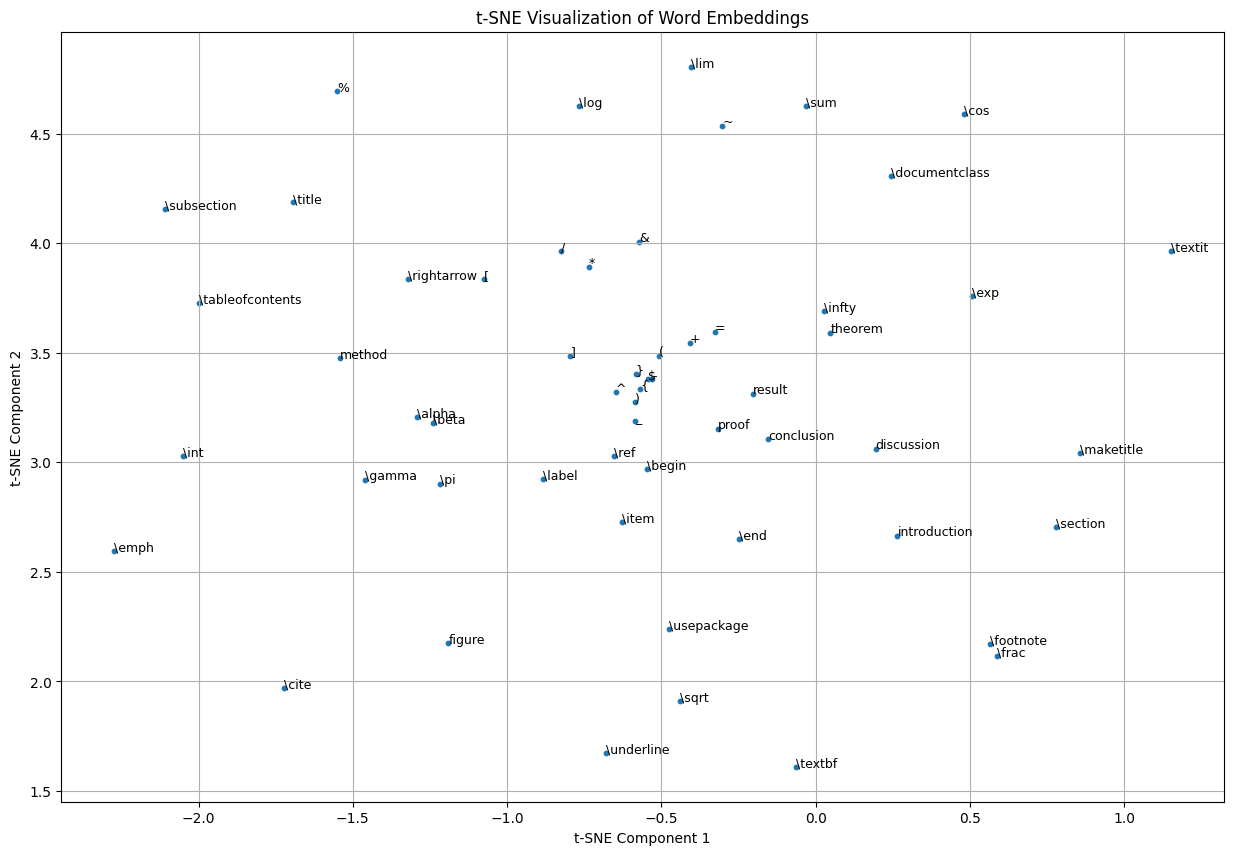

In [12]:
visualize_embeddings(model, word_to_ix, words_to_plot, SEED)

## 1.5 Comparative Analysis

### Dataset Overview
| Aspect | Category I: Natural Language | Category II: Structured/Domain Text |
|--------|------------------------------|------------------------------------|
| Example | Paul Graham essays, Shakespeare, Leo Tolstoy's War and Peace, The Adventures of Sherlock Holmes, by Arthur Conan Doyle | Latex Maths book |
| Dataset Size | ~2218269 data points | ~8468286 data points |
| Vocabulary | 47857 words | 12997 tokens |
| Predictability | Moderate–low | Relatively High (repetitive patterns) |

---

### Model Performance
| Metric | Natural Language | Structured Text |
|--------|------------------|-----------------|
| Final Val. Loss | ~5 | ~2.2 |
| Val. Accuracy | ~13% | ~50% |
| Qualitative Output | Able to recognize the grammar, but prone to lots of errors | Able to recognize the syntax |

**Comment:**  
The MLP learns structured text faster because of strict syntax and fewer valid continuations.  
Natural text is harder due to high variability and richer semantics.

---

### Embedding Visualization
| Observation | Natural Language | Structured Text |
|--------------|-----------------|-----------------|
| Clustering | By semantics (nouns, verbs, adjectives) | By syntax (keywords, operators) |
| Example Groups | (great, good), (startup, startups), (go, do, does, did) | (}, {, ., +, =, (, )), (\alpha, \beta), (\begin, \item, \ref, \end) |

**Interpretation:**  
Natural text embeddings capture *semantic similarity*, while structured text embeddings capture *syntactic roles*.

---

### Summary Insights
- Structured datasets are **easier to learn**, with faster convergence and higher accuracy.  
- Natural language models show **semantic depth** but higher uncertainty.  
- Structured embeddings reflect **syntax**, while natural ones reflect **meaning**.  
- In short: *structured = easier but shallow; natural = harder but rich*.
